In [93]:
import numpy as np
import copy
import matplotlib.pyplot as plt
from scipy import ndimage
from lr_utils import load_dataset
import h5py

to build a image recognition that classify it is cat or not

In [95]:
tain_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

y = [0], it's a 'non-cat' picture.


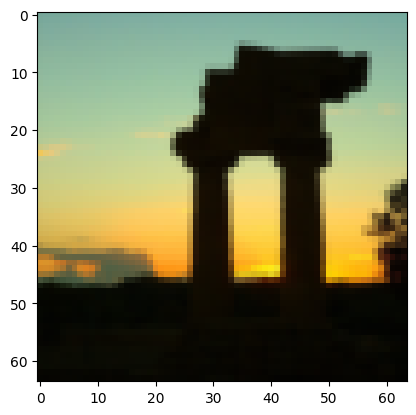

In [96]:
index=40
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

<h4>keep in mind that matrix/vector dimensions should be correct</h4>

In [98]:
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]


print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


In [99]:
#reshape image (num_px, num_px, 3) to (num_px*num_px*3,1) make a vector array
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0],-1).T
#X = (features, examples
assert np.alltrue(train_set_x_flatten[0:10, 1] == [196, 192, 190, 193, 186, 182, 188, 179, 174, 213]), "Wrong solution. Use (X.shape[0], -1).T."
assert np.alltrue(test_set_x_flatten[0:10, 1] == [115, 110, 111, 137, 129, 129, 155, 146, 145, 159]), "Wrong solution. Use (X.shape[0], -1).T."

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


In [100]:
#comman way to preprocessing is to center and standardize your dataset,
#standardize in image simply divide by 255
train_set_x = train_set_x_flatten / 255
test_set_x = test_set_x_flatten / 255

<font color='red'>
    
    
**What you need to remember:**

Common steps for pre-processing a new dataset are:
- Figure out the dimensions and shapes of the problem (m_train, m_test, num_px, ...)
- Reshape the datasets such that each example is now a vector of size (num_px \* num_px \* 3, 1)
- "Standardize" the data

<h3>Architecture of learning algorithm</h3>

initialize the parameters -> learn from model and minimizing the cost -> use that learned parameters to make predictions

<h3>building neural networks</h3>

1. define model structure like input features
2. initialize the model parameters
3. loop
   1. forward propagation (calculate the loss)
   2. backward propagation ( calculate the graadient)
   3. update the parameters


In [105]:
#making sigmoid function
def sigmoid(z):
    """
    compute the sigmois of z 

    return s -- sigmoid(z)
    """
    s = 1 /(1 + (np.exp(-z)))
    return s

In [106]:
x = np.array([0.5, 0, 2.0])
output = sigmoid(x)
print(output)

[0.62245933 0.5        0.88079708]


In [107]:
#initialize the parameters
def initialize_with_zeros(dim):
    """
    creating a vector with zero shapes(dim,1) for w and b = 0

    Return 
    w -- inintialized vector of shape(dim,1)
    b --initialized scaler
    """
    w = np.zeros((dim,1))
    b = 0.0


    return w, b

In [108]:
dim = 2
w, b = initialize_with_zeros(dim)
print(w,b)

[[0.]
 [0.]] 0.0


<h4>forward propagation and backward</h4>

In [110]:
def propagate(w, b, X, Y):
    """
    implement cost function and calculate the gradient 

    Return:
    grads -- dw and db and it will be same shape as previous
    cost 
    """
    m = X.shape[0]
    #forward propagation
    A = 1 / (1 + np.exp(-(np.dot(w.T,X) + b)))
    cost = (-1/m)* np.sum(Y * np.log(A) + (1 - Y) * np.log(1-A))

    #Backward propagation 
    dw = (1/m) * np.dot(X, (A-Y).T)
    db = (1/m) * np.dot(A-Y)

    cost = np.squeeze(np.array(cost))
    grads = {"dw" : dw,
             "db" : db}
    return grads , cost
    

<h3>Optimization</h3>

now time to update the parameters using gradient descent s


In [112]:
def optimize(w, b, X, Y, num_iteration= 100, learning_rate = 0.009, print_cost = False):
    """
    w --weight, numpy array(num_px*num_px * 3,1)
    b --bias, scaler
    X --data shape(num_px*num_px * 3 , number of examples)
    Y --true/false (1, number of examples)

    Return
    params
    grads
    cost

    what we have to do:
    1. calculate the cost and the gradinet for the current parameters 
    2.udate the pareameters 
    """
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)

    cost = []#creating a list

    for i in range(num_iteration):
        grads, cost = propagate(w, b, X, Y)#prediction, cost 

        #getting the gradients
        dw = grads["dw"]
        db = grads["db"]

        #update the gradeints
        w = w -learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            cost.append(cost)
            if print_cost:
                print("cost after iteration %i: %f" %(i, cost))

    params = {"w": w,
              "b": b}
    
    grads = {"dw": dw,
             "db": db}
    
    return params, grads, costs

<h4>prediction
</h4>

In [114]:
def predict(w, b , X):
    """
    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar 
    X -- data of size (num_px * num_px * 3, number of examples)
    
    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    """
    m = X.shape[1]
    y_prediction = np.zeros((1,m))#empyt array to store prediction
    w = w.reshape(X.shape[0],1)

    A = 1/ (1 + np.exp(-(np.dot(w.T,X)+b)))

    for i in range(A.shape[1]):
        if A[0,i] > 0.5:
            y_prediction[0, i] = 1.0
        else:
            y_prediction[0,i] = 0

    return y_prediction
    

<h3>Merge all function into a model</h3>

In [ ]:
#now put all the things together to build a model
def model (X_train, Y_train, X_test, Y_test, num_iteration = 2000, learning_rate = 0.5, print_cost = False):
    